# 학습 목표
- Iceberg 에서 중첩된 JSON 필드를 파티션으로 이용하는 방법을 알아본다.

---

In [38]:
import json
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from IPython.display import Image
from utils.get_iceberg_metadata import get_metadata
from utils.iceberg_metadata_properties import IcebergMetadataJsonField, FIELD_DESCRIPTIONS

---

# 중첩된 JSON 필드 
- 아래 출력 예시와 같이 payload 필드의 device, country 란는 중첩 필드가 존재한다.
- country 기준으로 테이블 파티션을 지정해본다.

In [9]:
# 중첩된 JSON 필드 예시 데이터
nested_json_file = "data/2_events.json"

with open(nested_json_file, "r", encoding="utf-8") as f:
    data = json.load(f) 

print(json.dumps(data, indent=4, ensure_ascii=False))

[
    {
        "event_ts": "2025-04-24T15:30:00Z",
        "user_id": 101,
        "payload": {
            "device": "mobile",
            "country": "IN"
        }
    },
    {
        "event_ts": "2025-04-25T09:12:00Z",
        "user_id": 102,
        "payload": {
            "device": "web",
            "country": "US"
        }
    }
]


---

# 중첩 필드로 파티션 지정하기

In [10]:
spark = SparkSession.builder \
    .appName("IcebergSparkWithMinIO") \
    .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
    .config("spark.sql.catalog.my_catalog.type", "rest") \
    .config("spark.sql.catalog.my_catalog.uri", "http://iceberg-rest:8181") \
    .config("spark.sql.catalog.my_catalog.warehouse", "s3://warehouse/") \
    .config("spark.sql.catalog.my_catalog.io-impl", "org.apache.iceberg.aws.s3.S3FileIO") \
    .config("spark.sql.catalog.my_catalog.s3.endpoint", "http://minio:9000") \
    .config("spark.sql.catalog.my_catalog.s3.access-key-id", "admin") \
    .config("spark.sql.catalog.my_catalog.s3.secret-access-key", "password") \
    .config("spark.sql.catalog.my_catalog.s3.path-style-access", "true") \
    .config("spark.jars.packages", "org.apache.iceberg:iceberg-spark3-runtime:1.2.0,org.apache.iceberg:iceberg-spark3:1.2.0") \
    .getOrCreate()

In [11]:
spark.sql("SHOW CATALOGS").show()

+-------------+
|      catalog|
+-------------+
|         demo|
|spark_catalog|
+-------------+



## 샘플 중첩 JSON 데이터프레임 생성하기

In [12]:
df = spark.read.option("multiline", "true").json(nested_json_file)
df.show()

+--------------------+------------+-------+
|            event_ts|     payload|user_id|
+--------------------+------------+-------+
|2025-04-24T15:30:00Z|{IN, mobile}|    101|
|2025-04-25T09:12:00Z|   {US, web}|    102|
+--------------------+------------+-------+



## 중첩 필드를 이용해서 파티션 지정한 테이블 생성하기

In [14]:
df.writeTo("my_catalog.my_database.events") \
    .partitionedBy(F.expr("payload.country")) \
    .createOrReplace()

In [21]:
spark.sql("SHOW CATALOGS").show(),
spark.sql("SHOW DATABASES").show(),
spark.sql("SHOW TABLES IN my_catalog.my_database").show(),
spark.sql("SELECT * FROM my_catalog.my_database.events").show()

+-------------+
|      catalog|
+-------------+
|         demo|
|   my_catalog|
|spark_catalog|
+-------------+

+-----------+
|  namespace|
+-----------+
|my_database|
+-----------+

+-----------+---------+-----------+
|  namespace|tableName|isTemporary|
+-----------+---------+-----------+
|my_database|   events|      false|
|my_database| my_table|      false|
+-----------+---------+-----------+

+--------------------+------------+-------+
|            event_ts|     payload|user_id|
+--------------------+------------+-------+
|2025-04-24T15:30:00Z|{IN, mobile}|    101|
|2025-04-25T09:12:00Z|   {US, web}|    102|
+--------------------+------------+-------+



## MinIO 파티션 디렉토리 확인하기

📋 MinIO 에 적재된 events 테이블 파티션
이미지와 같이 payload 하위에 존재하는 country 필드를 기준으로 디렉토리가 구분되어 파티셔닝 된 것을 볼 수 있다.


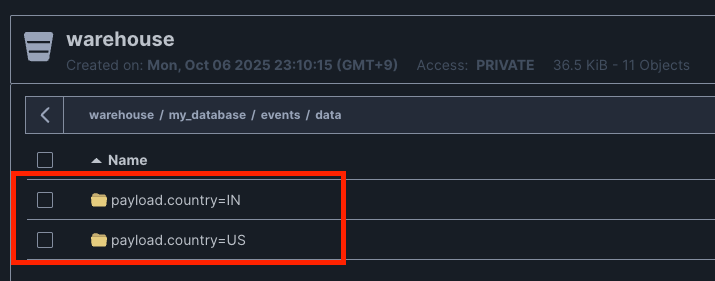

In [23]:
print("📋 MinIO 에 적재된 events 테이블 파티션")
print("이미지와 같이 payload 하위에 존재하는 country 필드를 기준으로 디렉토리가 구분되어 파티셔닝 된 것을 볼 수 있다.")
Image("/home/iceberg/notebooks/images/2_partition_of_nested_json_field.png")

## 테이블 스키마 확인하기
- `PARTITIONED BY (payload.country)` 와 같이 country 필드로 파티션 속성이 설정되어있다.

In [26]:
spark.sql("SHOW CREATE TABLE my_catalog.my_database.events").show(truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|createtab_stmt                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
+-----------------------------------------------------------------------------

## 테이블 메타데이터 내용 확인해보기

In [27]:
! curl -s http://iceberg-rest:8181/v1/namespaces/my_database/tables/events

{"metadata-location":"s3://warehouse/my_database/events/metadata/00000-9804d3e0-d1fb-4cd6-b7b5-992c4d0ea3f4.metadata.json","metadata":{"format-version":2,"table-uuid":"39d9cf2e-0155-4046-a895-f264d59dd407","location":"s3://warehouse/my_database/events","last-sequence-number":1,"last-updated-ms":1759763557062,"last-column-id":5,"current-schema-id":0,"schemas":[{"type":"struct","schema-id":0,"fields":[{"id":1,"name":"event_ts","required":false,"type":"string"},{"id":2,"name":"payload","required":false,"type":{"type":"struct","fields":[{"id":4,"name":"country","required":false,"type":"string"},{"id":5,"name":"device","required":false,"type":"string"}]}},{"id":3,"name":"user_id","required":false,"type":"long"}]}],"default-spec-id":0,"partition-specs":[{"spec-id":0,"fields":[{"name":"payload.country","transform":"identity","source-id":4,"field-id":1000}]}],"last-partition-id":1000,"default-sort-order-id":0,"sort-orders":[{"order-id":0,"fields":[]}],"properties":{"owner":"root","created-at":

In [39]:
metadata_json = "00000-9804d3e0-d1fb-4cd6-b7b5-992c4d0ea3f4.metadata.json"
obj = get_metadata(file_name=metadata_json, table='events')
metadata_json = json.loads(obj["Body"].read().decode("utf-8"))

for key in IcebergMetadataJsonField:
    print(f"🔑'KEY':{key.value}({FIELD_DESCRIPTIONS[key]})\n ▶︎'VALUE':{metadata_json[key.value]}")
    print("-"*100)

print("\n📋 메타데이터 원본 JSON")
print(json.dumps(metadata_json, indent=2, ensure_ascii=False))

🔑'KEY':format-version(Iceberg 테이블 포맷 버전(https://iceberg.apache.org/spec/))
 ▶︎'VALUE':2
----------------------------------------------------------------------------------------------------
🔑'KEY':table-uuid(테이블을 고유하게 식별하는 UUID(테이블 변경, 데이터 갱신에도 변경되지 않는 정보))
 ▶︎'VALUE':39d9cf2e-0155-4046-a895-f264d59dd407
----------------------------------------------------------------------------------------------------
🔑'KEY':location(테이블 데이터와 메타데이터가 저장되는 경로)
 ▶︎'VALUE':s3://warehouse/my_database/events
----------------------------------------------------------------------------------------------------
🔑'KEY':last-sequence-number(마지막으로 커밋된 작업의 시퀀스 번호 (트랜잭션 순서, 테이블 또는 데이터 갱신 작업마다 늘어남))
 ▶︎'VALUE':1
----------------------------------------------------------------------------------------------------
🔑'KEY':last-updated-ms(메타데이터가 마지막으로 갱신된 시각 (epoch 밀리초))
 ▶︎'VALUE':1759763557062
----------------------------------------------------------------------------------------------------
🔑'KEY':last-column-id(테이블에서